<a href="https://colab.research.google.com/github/lexusbt/hybrid-classical-quantum/blob/master/When_Graphs_Change_Hands_on_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# When Graphs Change: Hands-on Exercise

In this exercise, we will explore how graph structure affects community detection.

We will:

1. Generate a synthetic network with communities.

2. Detect communities.

3. Perturb the graph.

4. Observe how the detected communities change.

In [ ]:
!pip -q install python-louvain

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from community import community_louvain
from sklearn.metrics import adjusted_rand_score

np.random.seed(7)

In [ ]:
def generate_sbm(n_per_community=40, p_in=0.25, p_out=0.02, seed=7):

    sizes = [n_per_community, n_per_community, n_per_community]

    probs = [
        [p_in,  p_out, p_out],
        [p_out, p_in,  p_out],
        [p_out, p_out, p_in],
    ]

    G = nx.stochastic_block_model(sizes, probs, seed=seed)
    true_labels = {}
    node = 0

    for c, size in enumerate(sizes):
        for _ in range(size):
            true_labels[node] = c
            node += 1

    return G, true_labels

def plot_graph(G, labels, title="Graph"):

    pos = nx.spring_layout(G, seed=4)
    colors = [labels[n] for n in G.nodes()]
    plt.figure(figsize=(6, 5))
    nx.draw_networkx_nodes(G, pos, node_color=colors, cmap="tab10", node_size=80)
    nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.8)
    plt.title(title)
    plt.axis("off")
    plt.show()

def detect_communities(G):

    partition = community_louvain.best_partition(G, random_state=7)

    return partition

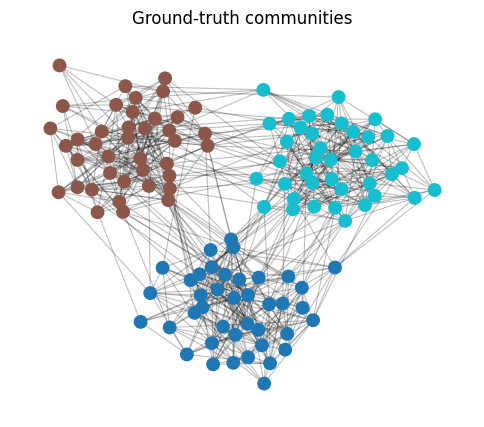

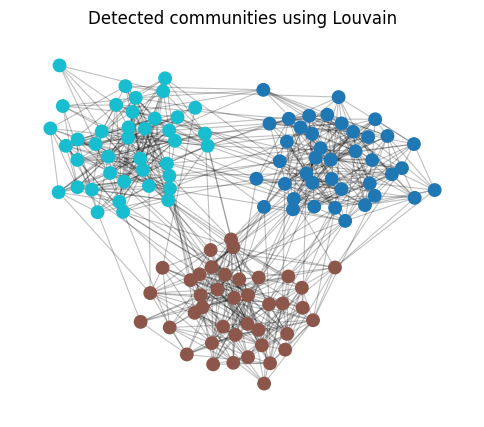

Agreement with ground truth (ARI): 1.000


In [ ]:
G, true_labels = generate_sbm(p_in=0.25, p_out=0.02)

detected_labels = detect_communities(G)
plot_graph(G, true_labels, "Ground-truth communities")
plot_graph(G, detected_labels, "Detected communities using Louvain")

ari = adjusted_rand_score([true_labels[n] for n in G.nodes()], [detected_labels[n] for n in G.nodes()])

print(f"Agreement with ground truth (ARI): {ari:.3f}")

## Experiment 1: What happens when communities become weaker?

Try changing `p_out`.

Small `p_out` means communities are well separated.

Large `p_out` means communities are more mixed.

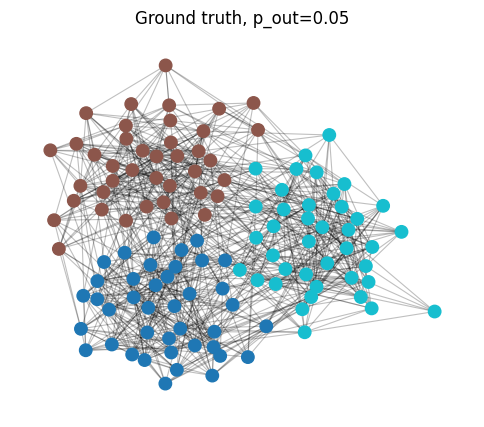

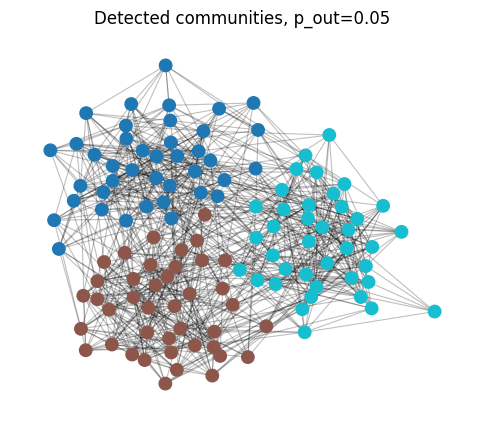

Agreement with ground truth (ARI): 0.950


In [ ]:
# Try values like 0.01, 0.03, 0.06, 0.10, 0.15

p_out = 0.05

G, true_labels = generate_sbm(p_in=0.25, p_out=p_out)
detected_labels = detect_communities(G)
plot_graph(G, true_labels, f"Ground truth, p_out={p_out}")
plot_graph(G, detected_labels, f"Detected communities, p_out={p_out}")

ari = adjusted_rand_score([true_labels[n] for n in G.nodes()], [detected_labels[n] for n in G.nodes()])

print(f"Agreement with ground truth (ARI): {ari:.3f}")

In [ ]:
def perturb_graph_random_edges(G, num_edges=5, seed=7):

    rng = np.random.default_rng(seed)
    H = G.copy()
    edges = list(H.edges())
    remove_edges = rng.choice(len(edges), size=min(num_edges, len(edges)), replace=False)

    for idx in remove_edges:
        H.remove_edge(*edges[idx])

    return H

def compare_before_after(G, H, title_before="Original", title_after="Perturbed"):

    labels_before = detect_communities(G)
    labels_after = detect_communities(H)

    plot_graph(G, labels_before, title_before)
    plot_graph(H, labels_after, title_after)

    similarity = adjusted_rand_score([labels_before[n] for n in G.nodes()], [labels_after[n] for n in H.nodes()])

    print(f"Partition similarity before vs after perturbation (ARI): {similarity:.3f}")

## Experiment 2: What happens after a small perturbation?

We remove a small number of random edges and compare the detected communities before and after.

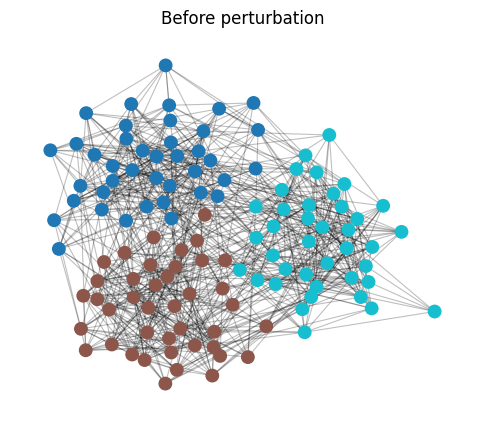

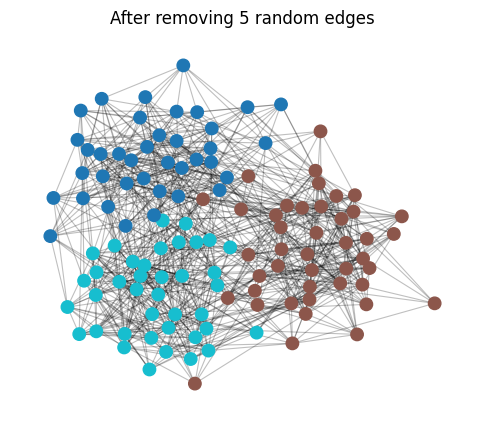

Partition similarity before vs after perturbation (ARI): 0.900


In [ ]:
G, true_labels = generate_sbm(p_in=0.25, p_out=0.05)

# Try values like 1, 3, 5, 10, 20

num_edges_to_remove = 5

H = perturb_graph_random_edges(G, num_edges=num_edges_to_remove)

compare_before_after(G, H, title_before="Before perturbation",title_after=f"After removing {num_edges_to_remove} random edges")

In [ ]:
def perturb_boundary_edges(G, true_labels, num_edges=5, seed=7):

    rng = np.random.default_rng(seed)
    H = G.copy()
    boundary_edges = [(u, v) for u, v in H.edges() if true_labels[u] != true_labels[v]]

    if len(boundary_edges) == 0:
        return H

    chosen = rng.choice(len(boundary_edges), size=min(num_edges, len(boundary_edges)), replace=False)

    for idx in chosen:
        H.remove_edge(*boundary_edges[idx])

    return H

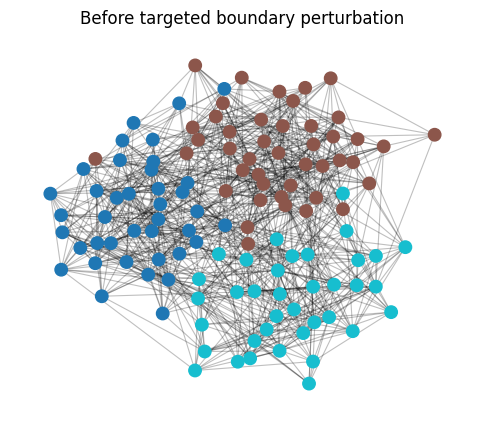

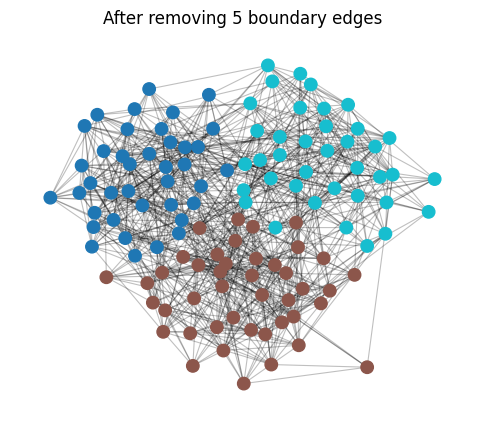

Partition similarity before vs after perturbation (ARI): 0.876


In [ ]:
G, true_labels = generate_sbm(p_in=0.25, p_out=0.06)

num_boundary_edges_to_remove = 5

H = perturb_boundary_edges(G, true_labels, num_edges=num_boundary_edges_to_remove)

compare_before_after(G, H, title_before="Before targeted boundary perturbation", title_after=f"After removing {num_boundary_edges_to_remove} boundary edges")

## Reflection questions

1. When are communities easy to recover?

2. What happens as `p_out` increases?

3. Are random perturbations and boundary perturbations equally disruptive?

4. Why might this matter for graph learning models?

5. How does this connect to robustness in GNN-based community detection?

# Advanced optional section: Embedding-based community detection

So far, we detected communities directly from the graph using Louvain.

Now we will use a simple embedding-based pipeline:

**Graph → spectral embedding → KMeans clustering → communities**

This is optional advanced material. It does not use a GNN, but it illustrates the same core idea from the lecture: graph structure can be transformed into an embedding space, and communities can then be recovered from that geometry.

In [ ]:
from sklearn.manifold import SpectralEmbedding
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
def compute_spectral_embeddings(G, dimensions=8, seed=7):

    A = nx.to_numpy_array(G, nodelist=list(G.nodes()))
    embedder = SpectralEmbedding(n_components=dimensions, affinity="precomputed", random_state=seed)
    embeddings = embedder.fit_transform(A)

    return embeddings

In [ ]:
def cluster_embeddings(embeddings, num_clusters=3, seed=7):

    kmeans = KMeans(n_clusters=num_clusters, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    return {node: int(label) for node, label in enumerate(labels)}

In [ ]:
def plot_embeddings_2d(embeddings, labels, title="Embedding space"):

    emb_2d = PCA(n_components=2, random_state=7).fit_transform(embeddings)
    colors = [labels[i] for i in range(len(labels))]

    plt.figure(figsize=(6, 5))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, cmap="tab10", s=50)
    plt.title(title)
    plt.xlabel("Embedding dimension 1")
    plt.ylabel("Embedding dimension 2")
    plt.show()

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x799950efa020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

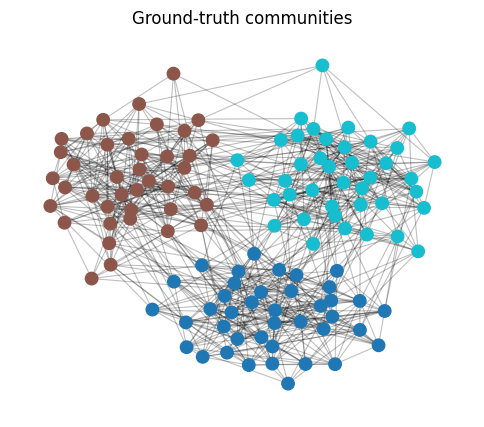

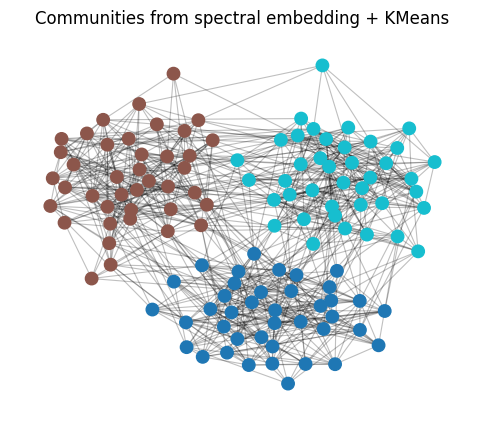

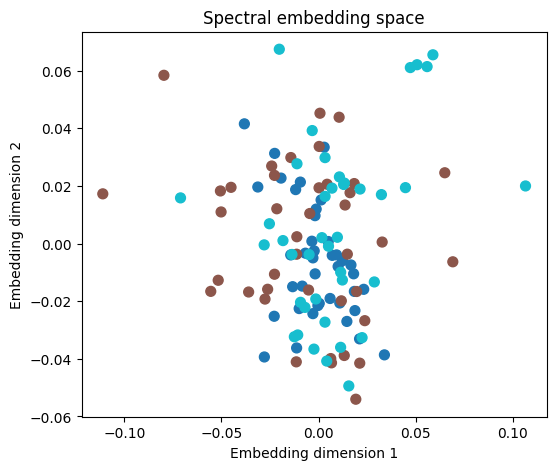

Agreement with ground truth (ARI): 1.000


In [ ]:
G, true_labels = generate_sbm(p_in=0.25, p_out=0.03)

embeddings = compute_spectral_embeddings(G)
embedding_labels = cluster_embeddings(embeddings, num_clusters=3)

plot_graph(G, true_labels, "Ground-truth communities")
plot_graph(G, embedding_labels, "Communities from spectral embedding + KMeans")
plot_embeddings_2d(embeddings, embedding_labels, "Spectral embedding space")

ari = adjusted_rand_score([true_labels[n] for n in G.nodes()], [embedding_labels[n] for n in G.nodes()])

print(f"Agreement with ground truth (ARI): {ari:.3f}")

## Experiment: What happens to the embedding after perturbation?

Now we perturb the graph, recompute the spectral embedding, recluster the nodes, and compare the detected communities before and after.

Try changing `num_edges`.

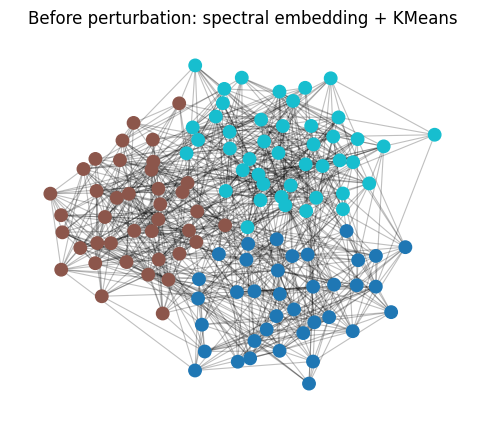

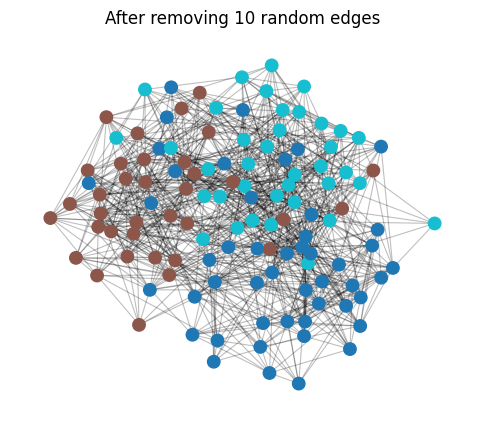

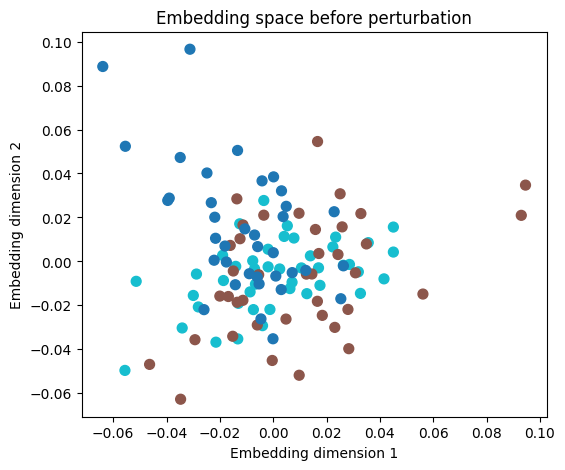

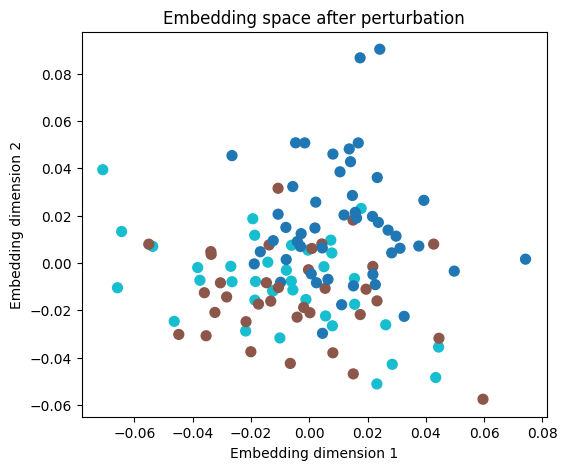

Partition similarity before vs after perturbation (ARI): 0.525


In [ ]:
G, true_labels = generate_sbm(p_in=0.25, p_out=0.06)

num_edges = 10
H = perturb_graph_random_edges(G, num_edges=num_edges)

emb_before = compute_spectral_embeddings(G)
emb_after = compute_spectral_embeddings(H)

labels_before = cluster_embeddings(emb_before, num_clusters=3)
labels_after = cluster_embeddings(emb_after, num_clusters=3)

plot_graph(G, labels_before, "Before perturbation: spectral embedding + KMeans")
plot_graph(H, labels_after, f"After removing {num_edges} random edges")

plot_embeddings_2d(emb_before, labels_before, "Embedding space before perturbation")
plot_embeddings_2d(emb_after, labels_after, "Embedding space after perturbation")

similarity = adjusted_rand_score([labels_before[n] for n in G.nodes()],[labels_after[n] for n in H.nodes()])

print(f"Partition similarity before vs after perturbation (ARI): {similarity:.3f}")

## Reflection questions

1. Are communities visible in the embedding space?
2. What changes after perturbing the graph?
3. Does spectral embedding + KMeans behave like Louvain, or differently?
4. Why might embedding-based community detection be sensitive to graph perturbations?
5. How does this connect to robustness in GNN-based community detection?

## Challenge

Can you design the smallest perturbation that causes the largest change in the recovered communities?

Try changing:

- p_out

- number of removed edges

- which edges are removed

Discuss your observations with your neighbor.